Метод Хука-Дживса: Тестирование на трёх функциях (3D)

Описание вариантов:

ТЕСТ 1: Розенброк (3D)

СРАВНЕНИЕ ВАРИАНТОВ для функции: Розенброк (3D)
Начальная точка: [0.5, 0.5, 0.5]

Вариант А:
  Количество точек в релаксационной последовательности: 4
  Количество точек поиска: 25
  Значение функции: 0.5199999999999997
  Результат: [0.7999999999999999, 0.6, 0.4]

Вариант Б:
  Количество точек в релаксационной последовательности: 2924
  Количество точек поиска: 17641
  Значение функции: 1.2111949837918954e-7
  Результат: [0.9998443603515551, 0.9996887207031103, 0.9993774414062204]


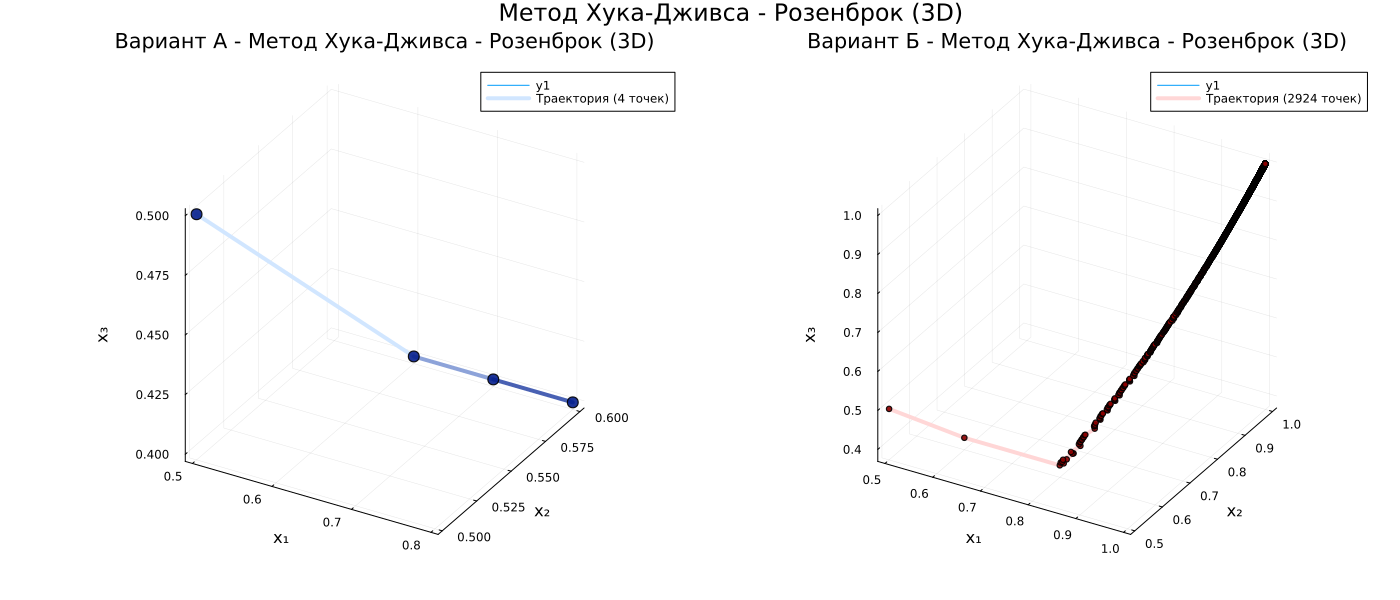


ТЕСТ 2: Растригин (3D)

СРАВНЕНИЕ ВАРИАНТОВ для функции: Растригин (3D)
Начальная точка: [0.5, 0.5, 0.5]

Вариант А:
  Количество точек в релаксационной последовательности: 6
  Количество точек поиска: 37
  Значение функции: -10.0
  Результат: [2.7755575615628914e-17, 2.7755575615628914e-17, 2.7755575615628914e-17]

Вариант Б:
  Количество точек в релаксационной последовательности: 2
  Количество точек поиска: 115
  Значение функции: -10.0
  Результат: [8.326672684688674e-17, 8.326672684688674e-17, 8.326672684688674e-17]


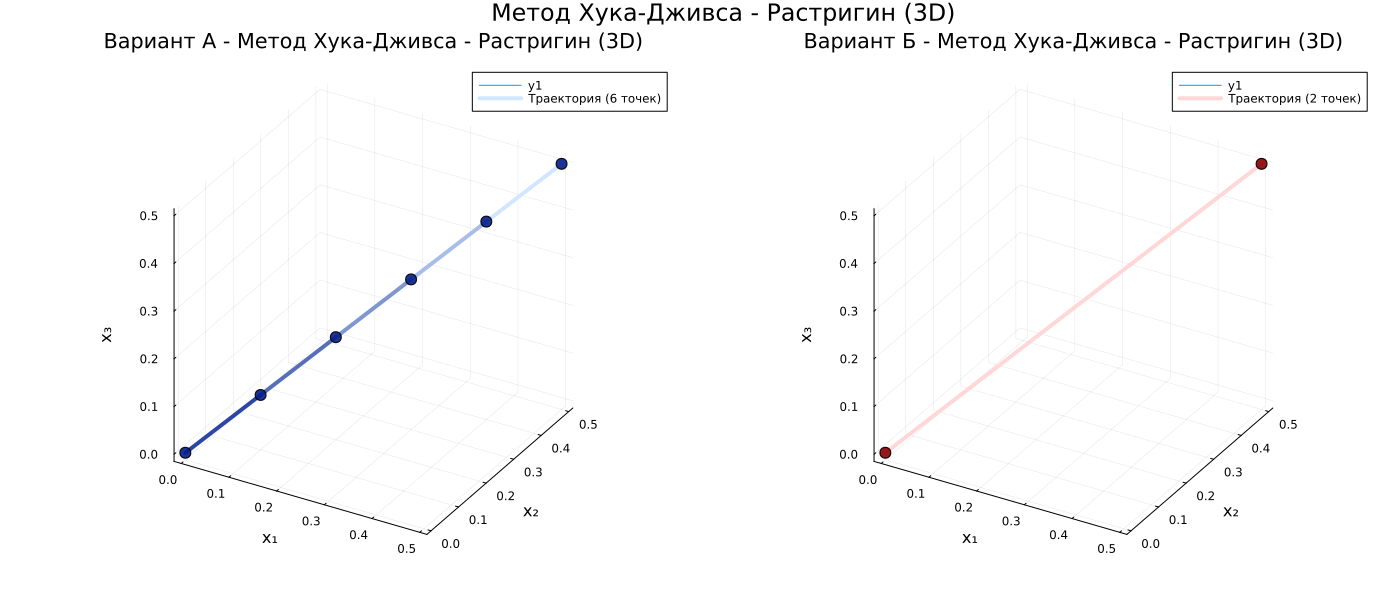


ТЕСТ 3: Швефель (3D)

СРАВНЕНИЕ ВАРИАНТОВ для функции: Швефель (3D)
Начальная точка: [0.5, 0.5, 0.5]

Вариант А:
  Количество точек в релаксационной последовательности: 48
  Количество точек поиска: 289
  Значение функции: 1245.113726032208
  Результат: [5.1999999999999975, 5.1999999999999975, 5.1999999999999975]

Вариант Б:
  Количество точек в релаксационной последовательности: 12
  Количество точек поиска: 175
  Значение функции: 1245.1127951241472
  Результат: [5.239199829101563, 5.239199829101563, 5.239199829101563]


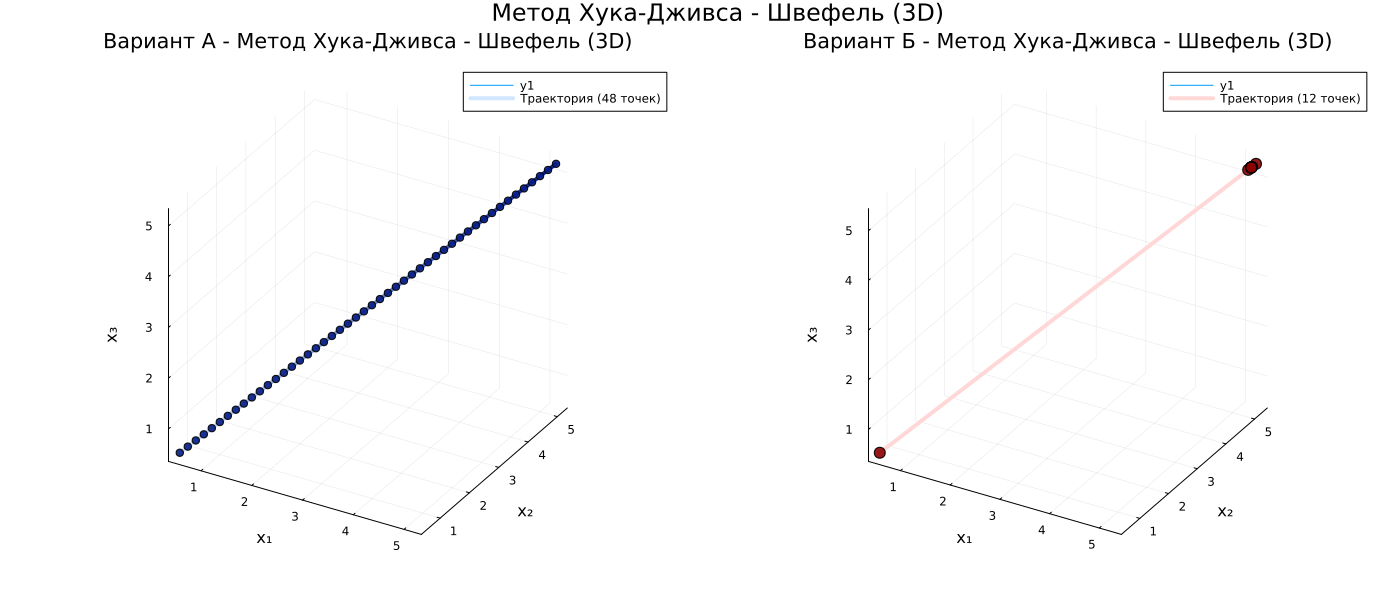


ПРИМЕР: Розенброк (3D) с точками поиска

СРАВНЕНИЕ ВАРИАНТОВ для функции: Розенброк (с точками поиска) (3D)
Начальная точка: [0.5, 0.5, 0.5]

Вариант А:
  Количество точек в релаксационной последовательности: 4
  Количество точек поиска: 25
  Значение функции: 0.5199999999999997
  Результат: [0.7999999999999999, 0.6, 0.4]

Вариант Б:
  Количество точек в релаксационной последовательности: 2924
  Количество точек поиска: 17641
  Значение функции: 1.2111949837918954e-7
  Результат: [0.9998443603515551, 0.9996887207031103, 0.9993774414062204]


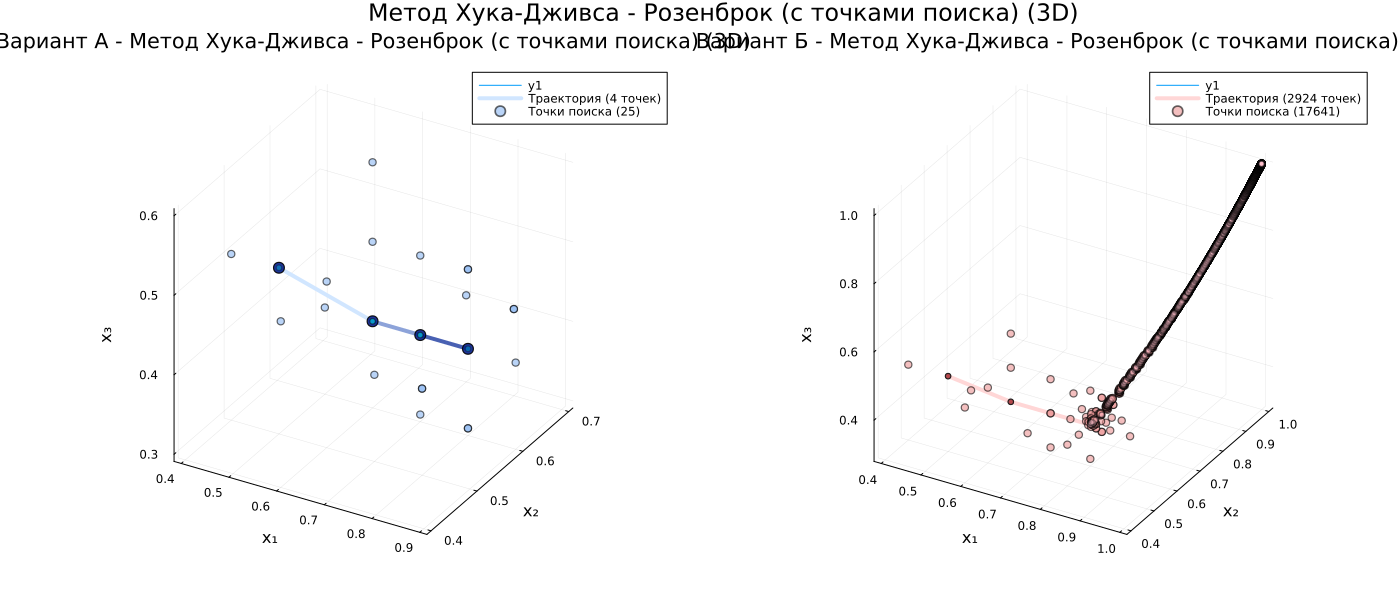

([0.7999999999999999, 0.6, 0.4], [[0.5, 0.5, 0.5], [0.6, 0.6, 0.4], [0.7, 0.6, 0.4], [0.7999999999999999, 0.6, 0.4]], [0.9998443603515551, 0.9996887207031103, 0.9993774414062204], [[0.5, 0.5, 0.5], [0.6, 0.6, 0.4], [0.7999999999999999, 0.6, 0.4], [0.7999999999999999, 0.65, 0.4], [0.7999999999999999, 0.625, 0.4], [0.7875, 0.625, 0.3875], [0.79375, 0.625, 0.3875], [0.7906249999999999, 0.625, 0.390625], [0.7906249999999999, 0.628125, 0.39375000000000004], [0.8031250000000001, 0.6406250000000002, 0.4062500000000002]  …  [0.9998413085937427, 0.9996810913085792, 0.9993606567382519], [0.9998413085937427, 0.9996810913085792, 0.9993621826171581], [0.9998413085937427, 0.9996841430663916, 0.9993652343749706], [0.9998428344726489, 0.9996841430663916, 0.9993667602538768], [0.9998428344726489, 0.9996841430663916, 0.9993682861327831], [0.9998428344726489, 0.9996871948242041, 0.9993713378905955], [0.9998443603515551, 0.9996871948242041, 0.9993728637695017], [0.9998443603515551, 0.9996871948242041, 0.9

In [1]:
using Plots
using LinearAlgebra
using Colors

gr()

function rosenbrock_3d(x)
    return (1.0 - x[1])^2 + 100.0*(x[2] - x[1]^2)^2 + (1.0 - x[2])^2 + 100.0*(x[3] - x[2]^2)^2
end

function rastrigin_3d(x)
    n = length(x)
    return 20 + sum(x[i]^2 - 10*cos(2*pi*x[i]) for i in 1:n)
end

function schwefel_3d(x)
    n = length(x)
    return 418.9829*n - sum(x[i]*sin(sqrt(abs(x[i]))) for i in 1:n)
end

# Вариант А:
function hooke_jeeves_variant_a(f, x0, eps=1e-6, delta0=0.1)
    n = length(x0)
    delta = fill(delta0, n)
    x = copy(x0)
    
    trajectory = [copy(x)]
    search_points = [copy(x)]
    max_points = []
    trajectory_colors = [:green]
    
    iteration = 0
    max_iterations = 10000
    
    while maximum(delta) > eps && iteration < max_iterations
        iteration += 1
        x_prev = copy(x)
        f_prev = f(x_prev)
        
        x_new = copy(x)
        improved = false
        
        for i in 1:n
            start_val = f(x_new)
            
            # +delta
            x_test_plus = copy(x_new)
            x_test_plus[i] += delta[i]
            f_test_plus = f(x_test_plus)
            
            # -delta
            x_test_minus = copy(x_new)
            x_test_minus[i] -= delta[i]
            f_test_minus = f(x_test_minus)
            
            push!(search_points, copy(x_test_plus))
            push!(search_points, copy(x_test_minus))
            
            if f_test_plus < start_val && f_test_plus < f_test_minus
                x_new = x_test_plus
                improved = true
            elseif f_test_minus < start_val
                x_new = x_test_minus
                improved = true
            end
        end
        
        if f(x_new) < f_prev
            x = copy(x_new)
            push!(trajectory, copy(x))
            push!(trajectory_colors, :green)
        else

            push!(max_points, copy(x))
            delta = delta / 2.0
            
            if maximum(delta) < eps || abs(f(x) - f_prev) < eps
                break
            end
        end
    end
    
    return x, trajectory, search_points, max_points, trajectory_colors
end

function exploratory_search(f, x, delta, include_start=true, add_to_search_points=true)
    n = length(x)
    x_new = copy(x)
    direction_points = include_start ? [copy(x)] : []

    for i in 1:n
        start_val = f(x_new)
        temp = x_new[i]
        
        # Пробуем +delta
        x_test_plus = copy(x_new)
        x_test_plus[i] = temp + delta[i]
        f_plus = f(x_test_plus)
        
        x_test_minus = copy(x_new)
        x_test_minus[i] = temp - delta[i]
        f_minus = f(x_test_minus)
        
        if add_to_search_points
            push!(direction_points, copy(x_test_plus))   # +delta
            push!(direction_points, copy(x_test_minus)) # -delta
        end
        
        if f_plus < start_val && f_plus < f_minus
            x_new = x_test_plus
        elseif f_minus < start_val
            x_new = x_test_minus
        end
    end

    return x_new, direction_points
end

function hooke_jeeves_variant_b(f, x0, eps=1e-6, delta0=0.1)
    n = length(x0)
    delta = fill(delta0, n)
    x = copy(x0)
    
    trajectory = [copy(x)]
    search_points = [copy(x)]
    max_points = []
    trajectory_colors = [:green]
    
    prev_dir = nothing
    iteration = 0
    max_iterations = 10000
    
    while maximum(delta) > eps && iteration < max_iterations
        iteration += 1
        
        x_exp, dir_pts = exploratory_search(f, x, delta, false)
        append!(search_points, dir_pts)
        
        if f(x_exp) >= f(x)
            push!(max_points, copy(x))
            if prev_dir !== nothing
                if length(trajectory) == 0 || norm(x - trajectory[end]) > eps
                    push!(trajectory, copy(x))
                    push!(trajectory_colors, :green)
                end
                prev_dir = nothing
            end
            delta = delta / 2.0
            continue
        end
        
        direction = x_exp - x
        step_size = norm(direction)
        
        if step_size < eps
            x = copy(x_exp)
            delta = delta / 2.0
            continue
        end
        
        dir_norm = direction / step_size
        
        direction_changed = true
        if prev_dir !== nothing
            cos_sim = dot(dir_norm, prev_dir) / (norm(dir_norm) * norm(prev_dir))
            if cos_sim > 0.95
                direction_changed = false
            end
        end
        
        if direction_changed && prev_dir !== nothing
            if length(trajectory) == 0 || norm(x - trajectory[end]) > eps
                push!(trajectory, copy(x))
                push!(trajectory_colors, :green)
            end
        end
        
        x_cur = copy(x_exp)
        f_cur = f(x_cur)
        cur_step = step_size
        
        while true
            x_next = x_cur + dir_norm * cur_step
            f_next = f(x_next)
            if f_next < f_cur
                x_cur = x_next
                f_cur = f_next
                cur_step *= 2.0
            else
                break
            end
        end
        
        x = copy(x_cur)
        prev_dir = copy(dir_norm)
        
        if maximum(delta) < eps
            break
        end
    end
    
    if length(trajectory) == 0 || norm(x - trajectory[end]) > eps
        push!(trajectory, copy(x))
        push!(trajectory_colors, :green)
    end
    
    return x, trajectory, search_points, max_points, trajectory_colors
end

function plot_trajectories_3d(f, x0, result_a, trajectory_a, search_points_a, 
                              result_b, trajectory_b, search_points_b, 
                              title_str, show_search_points=false)
    function get_line_style(base_color)
        if base_color == :blue
            light = RGB(0.82, 0.90, 1.00)
            dark  = RGB(0.02, 0.12, 0.55)
            line_cgrad = cgrad([light, dark])
            marker_color = dark
            search_color = RGB(0.55, 0.72, 0.95)
        else
            light = RGB(1.00, 0.84, 0.84)
            dark  = RGB(0.55, 0.00, 0.00)
            line_cgrad = cgrad([light, dark])
            marker_color = dark
            search_color = RGB(0.92, 0.58, 0.58)
        end
        return line_cgrad, marker_color, search_color
    end
    
    function plot_single_trajectory(trajectory, result, search_points, x0, 
                                    base_color, variant_name, show_search)
        plt = plot([], [], [],
            seriestype=:path3d,
            xlabel="x₁", 
            ylabel="x₂", 
            zlabel="x₃",
            title=variant_name,
            legend=:topright,
            size=(600, 500)
        )
        
        line_cgrad, marker_color, search_color = get_line_style(base_color)

        if length(trajectory) > 1
            x_vals = [p[1] for p in trajectory]
            y_vals = [p[2] for p in trajectory]
            z_vals = [p[3] for p in trajectory]

            line_progress = collect(range(0.0, 1.0, length=length(trajectory)))

            plot!(plt,
                x_vals,
                y_vals,
                z_vals,
                seriestype=:path3d,
                line_z=line_progress,
                linecolor=line_cgrad,
                linewidth=4,
                colorbar=false,
                label="Траектория ($(length(trajectory)) точек)"
            )
            
            ms = length(trajectory) <= 15 ? 6 : (length(trajectory) <= 50 ? 4 : 3)
            scatter!(plt, 
                x_vals,
                y_vals,
                z_vals,
                color=marker_color, 
                markersize=ms,
                alpha=0.9,
                seriestype=:scatter3d,
                marker=:circle,
                label=""
            )
        elseif length(trajectory) == 1
            scatter!(plt, 
                [trajectory[1][1]], 
                [trajectory[1][2]], 
                [trajectory[1][3]], 
                color=base_color, 
                markersize=8,
                alpha=0.9,
                seriestype=:scatter3d,
                label="Траектория (1 точка)"
            )
        end
        
        if show_search && length(search_points) > 0
            trajectory_set = Set([(round(p[1], digits=10), round(p[2], digits=10), round(p[3], digits=10)) for p in trajectory])
            
            search_not_in_trajectory = []
            search_in_trajectory = []
            
            for p in search_points
                point_tuple = (round(p[1], digits=10), round(p[2], digits=10), round(p[3], digits=10))
                if point_tuple in trajectory_set
                    push!(search_in_trajectory, p)
                else
                    push!(search_not_in_trajectory, p)
                end
            end
            
            if length(search_not_in_trajectory) > 0
                scatter!(plt, 
                    [p[1] for p in search_not_in_trajectory], 
                    [p[2] for p in search_not_in_trajectory], 
                    [p[3] for p in search_not_in_trajectory], 
                    color=search_color, 
                    markersize=4,
                    alpha=0.6,
                    seriestype=:scatter3d,
                    label="Точки поиска ($(length(search_points)))"
                )
            end
            
            if length(search_in_trajectory) > 0
                scatter!(plt, 
                    [p[1] for p in search_in_trajectory], 
                    [p[2] for p in search_in_trajectory], 
                    [p[3] for p in search_in_trajectory], 
                    color=(base_color == :blue ? :cyan : :pink), 
                    markersize=3,
                    alpha=0.3,
                    seriestype=:scatter3d,
                    label=""
                )
            end
            

        end
        
        start_is_first = length(trajectory) > 0 && 
                         abs(x0[1] - trajectory[1][1]) < 1e-10 && 
                         abs(x0[2] - trajectory[1][2]) < 1e-10 && 
                         abs(x0[3] - trajectory[1][3]) < 1e-10
        
        if !start_is_first
            scatter!(plt, [x0[1]], [x0[2]], [x0[3]], 
                color=:yellow, 
                markersize=10, 
                alpha=0.9,
                seriestype=:scatter3d,
                marker=:circle,
                label="Старт"
            )
        end

        return plt
    end
    
    plt_a = plot_single_trajectory(trajectory_a, result_a, search_points_a, x0, 
                                   :blue, "Вариант А - " * title_str, show_search_points)
    plt_b = plot_single_trajectory(trajectory_b, result_b, search_points_b, x0, 
                                   :red, "Вариант Б - " * title_str, show_search_points)
    
    plt_combined = plot(plt_a, plt_b, 
        layout=(1, 2),
        size=(1400, 600),
        plot_title=title_str
    )
    
    return plt_combined
end

function compare_variants_3d(f, f_name, x0, show_search_points=false, show_plot=true)
    println("\n" * "="^60)
    println("СРАВНЕНИЕ ВАРИАНТОВ для функции: $f_name (3D)")
    println("Начальная точка: $x0")
    println("="^60)
    
    result_a, trajectory_a, search_points_a, max_points_a, _ = hooke_jeeves_variant_a(f, x0)
    
    result_b, trajectory_b, search_points_b, max_points_b, _ = hooke_jeeves_variant_b(f, x0)
    
    println("\nВариант А:")
    println("  Количество точек в релаксационной последовательности: $(length(trajectory_a))")
    println("  Количество точек поиска: $(length(search_points_a))")
    println("  Значение функции: $(f(result_a))")
    println("  Результат: $result_a")
    
    println("\nВариант Б:")
    println("  Количество точек в релаксационной последовательности: $(length(trajectory_b))")
    println("  Количество точек поиска: $(length(search_points_b))")
    println("  Значение функции: $(f(result_b))")
    println("  Результат: $result_b")
    
    title_str = "Метод Хука-Дживса - $f_name (3D)"
    plt = plot_trajectories_3d(f, x0, result_a, trajectory_a, search_points_a,
                               result_b, trajectory_b, search_points_b,
                               title_str, show_search_points)
    
    if show_plot
        display(plt)
    end
    
    return result_a, trajectory_a, result_b, trajectory_b, plt
end

println("Метод Хука-Дживса: Тестирование на трёх функциях (3D)")
println("\nОписание вариантов:")


# Тест 1: Розенброк (3D)
x0_rosenbrock_3d = [0.5, 0.5, 0.5]
println("\n" * "="^80)
println("ТЕСТ 1: Розенброк (3D)")
println("="^80)
result_a1, traj_a1, result_b1, traj_b1, plt1 = compare_variants_3d(rosenbrock_3d, "Розенброк", x0_rosenbrock_3d, false)

# Тест 2: Растригин (3D)
x0_rastrigin_3d = [0.5, 0.5, 0.5]
println("\n" * "="^80)
println("ТЕСТ 2: Растригин (3D)")
println("="^80)
result_a2, traj_a2, result_b2, traj_b2, plt2 = compare_variants_3d(rastrigin_3d, "Растригин", x0_rastrigin_3d, false)

# Тест 3: Швефель (3D)
x0_schwefel_3d = [0.5, 0.5, 0.5]
println("\n" * "="^80)
println("ТЕСТ 3: Швефель (3D)")
println("="^80)
result_a3, traj_a3, result_b3, traj_b3, plt3 = compare_variants_3d(schwefel_3d, "Швефель", x0_schwefel_3d, false)

# Пример с включёнными точками поиска для Розенброка
println("\n" * "="^80)
println("ПРИМЕР: Розенброк (3D) с точками поиска")
println("="^80)
_, _, _, _, plt1_with_search = compare_variants_3d(rosenbrock_3d, "Розенброк (с точками поиска)", x0_rosenbrock_3d, true)